# 🎬 Data Analysis with Netflix Data
### Learning Statistics + Visualisation with Pandas & Matplotlib
**Dataset:** netflix_titles.csv &nbsp;|&nbsp; **Tools:** Python, Pandas, Matplotlib

---
> **How this notebook works:** Every concept we learn answers a *real question* about Netflix data.
> We never learn a function just because it exists — we learn it because we need it.


---
## 📦 Step 1 — Import Libraries & Load the Data

Before anything else, we bring in our tools and load the dataset.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset — make sure netflix_titles.csv is in the same folder as this notebook
df = pd.read_csv("netflix_titles.csv")

print("Dataset loaded!")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")


Dataset loaded!
Rows: 6234  |  Columns: 12


### 👀 Let's take a first look at the data


In [27]:
# Show the first 5 rows
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [28]:
# What columns do we have?
df.columns.tolist()


['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [29]:
# What types of data are in each column?
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


In [30]:
# Are there any missing values?
df.isnull().sum()


show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

> 💡 **Notice:** Some columns like `director` and `cast` have missing values.
> Real-world data is always messy — that is normal and expected.


---
## 🔍 Step 2 — Getting to Know the Data

Before calculating anything, let's ask some simple questions.


### ❓ Question 1: How many Movies vs TV Shows are there?


In [31]:
df['type'].value_counts()


type
Movie      4265
TV Show    1969
Name: count, dtype: int64

### ❓ Question 2: Which countries produce the most Netflix content?


In [32]:
df['country'].value_counts().head(10)


country
United States     2032
India              777
United Kingdom     348
Japan              176
Canada             141
South Korea        136
Spain              117
France              90
Mexico              83
Turkey              79
Name: count, dtype: int64

### ❓ Question 3: What ratings does Netflix use most?


In [33]:
df['rating'].value_counts()


rating
TV-MA       2027
TV-14       1698
TV-PG        701
R            508
PG-13        286
NR           218
PG           184
TV-Y7        169
TV-G         149
TV-Y         143
TV-Y7-FV      95
G             37
UR             7
NC-17          2
Name: count, dtype: int64

---
## 📊 Step 3 — Descriptive Statistics

Now we start answering the big question:
### *"How long is a typical Netflix movie?"*

We will use five statistical tools to answer this — each one tells us something different.


In [36]:
print(type(df))
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
(6234, 12)


In [37]:
print(df['type'].unique())

['Movie' 'TV Show']


In [41]:
# Run this cell — I have prepared this for you
movies = df[df['type'] == 'Movie'].copy()
movies['duration_mins'] = movies['duration'].str.split(' ').str[0].astype(float)

print("Ready! We have", len(movies), "movies to analyse.")

Ready! We have 4265 movies to analyse.


---
### 📐 Mean (Average)

The **mean** adds up all values and divides by the count.
It gives us the *mathematical* centre of the data.

$$\text{Mean} = \frac{\text{Sum of all values}}{\text{Number of values}}$$


In [40]:
mean_duration = movies['duration_mins'].mean()
print(f"Mean movie duration: {mean_duration:.1f} minutes")


Mean movie duration: 99.1 minutes


> 💡 **Interpretation:** On average, a Netflix movie is about this many minutes long.
> But is the "average" the best summary? Let's check the other measures.


---
### 🎯 Median (Middle Value)

The **median** is the value exactly in the middle when all values are sorted.
It is less affected by extreme values (very short or very long movies).


In [11]:
median_duration = movies['duration_mins'].median()
print(f"Median movie duration: {median_duration:.1f} minutes")


Median movie duration: 98.0 minutes


In [12]:
# Let's compare mean vs median
print(f"Mean:   {mean_duration:.1f} mins")
print(f"Median: {median_duration:.1f} mins")
print()
if mean_duration > median_duration:
    print("The mean is HIGHER than the median.")
    print("This suggests some very LONG movies are pulling the average up.")
else:
    print("The mean is LOWER than the median.")
    print("This suggests some very SHORT movies are pulling the average down.")


Mean:   99.1 mins
Median: 98.0 mins

The mean is HIGHER than the median.
This suggests some very LONG movies are pulling the average up.


> 💡 **Key insight:** When mean and median are different, it means the data is *skewed*.
> For example, a few 3-hour epic films can pull the mean up without affecting the median much.


---
### 🏆 Mode (Most Frequent Value)

The **mode** is the value that appears most often in the dataset.
For movie durations, it tells us: *"What length do Netflix movies aim for most?"*


In [13]:
mode_duration = movies['duration_mins'].mode()[0]
print(f"Mode movie duration: {mode_duration:.0f} minutes")
print()
print("Top 5 most common movie durations:")
movies['duration_mins'].value_counts().head()


Mode movie duration: 90 minutes

Top 5 most common movie durations:


duration_mins
90.0    111
91.0    104
92.0    101
95.0     94
94.0     94
Name: count, dtype: int64

> 💡 **Notice:** The mode reveals what duration Netflix movies *cluster around* the most.
> This is useful for understanding patterns that averages can hide.


---
### 📋 Summary So Far — Mean, Median, Mode Together


In [14]:
print("=" * 40)
print("   SUMMARY: Netflix Movie Durations")
print("=" * 40)
print(f"  Mean   (average)  : {mean_duration:.1f} mins")
print(f"  Median (middle)   : {median_duration:.1f} mins")
print(f"  Mode   (most freq): {mode_duration:.0f} mins")
print("=" * 40)


   SUMMARY: Netflix Movie Durations
  Mean   (average)  : 99.1 mins
  Median (middle)   : 98.0 mins
  Mode   (most freq): 90 mins


---
### 📏 Variance — How Spread Out Is the Data?

Mean, median, and mode all tell us about the *centre* of the data.
But they don't tell us how spread out the values are.

**Variance** measures how far each value is from the mean, on average.

$$\text{Variance} = \frac{\sum (x - \bar{x})^2}{n}$$

- Low variance = movies are all similar in length
- High variance = movie lengths vary a lot


In [15]:
variance_duration = movies['duration_mins'].var()
print(f"Variance of movie durations: {variance_duration:.1f}")


Variance of movie durations: 788.2


> 💡 **Problem with variance:** The unit is "minutes squared" — hard to interpret directly.
> That's why we use Standard Deviation instead.


---
### 📉 Standard Deviation — Variance in Plain English

**Standard Deviation** is simply the square root of variance.
It gives us spread in the *same unit* as our data (minutes).

$$\text{Std Dev} = \sqrt{\text{Variance}}$$

It tells us: *"Most movies fall within ± this many minutes of the mean."*


In [16]:
std_duration = movies['duration_mins'].std()
print(f"Standard Deviation: {std_duration:.1f} minutes")
print()
print(f"Most Netflix movies are between:")
print(f"  {mean_duration - std_duration:.0f} mins  and  {mean_duration + std_duration:.0f} mins")
print(f"  (Mean ± 1 Standard Deviation)")


Standard Deviation: 28.1 minutes

Most Netflix movies are between:
  71 mins  and  127 mins
  (Mean ± 1 Standard Deviation)


> 💡 **Rule of thumb:** In a normal distribution, about 68% of values fall within
> 1 standard deviation of the mean. Let's verify this with our data!


In [17]:
# What percentage of movies fall within 1 standard deviation of the mean?
lower = mean_duration - std_duration
upper = mean_duration + std_duration

within_1std = movies[(movies['duration_mins'] >= lower) & (movies['duration_mins'] <= upper)]
percentage = (len(within_1std) / len(movies)) * 100

print(f"Range: {lower:.0f} to {upper:.0f} minutes")
print(f"Movies in this range: {len(within_1std)} out of {len(movies)}")
print(f"Percentage: {percentage:.1f}%")


Range: 71 to 127 minutes
Movies in this range: 3102 out of 4265
Percentage: 72.7%


---
### ⚡ The Shortcut — `describe()`

Pandas can calculate all of this in one single line!


In [18]:
movies['duration_mins'].describe()


count    4265.000000
mean       99.100821
std        28.074857
min         3.000000
25%        86.000000
50%        98.000000
75%       115.000000
max       312.000000
Name: duration_mins, dtype: float64

> 💡 **Tip:** `.describe()` gives you count, mean, std, min, quartiles, and max instantly.
> It is always the first thing to run when exploring a new dataset.


---
## 🎨 Step 4 — Visualisation with Matplotlib

Numbers alone can be hard to interpret. Charts make patterns immediately visible.
We will now visualise everything we just calculated.


---
### 📊 Chart 1 — Histogram: Distribution of Movie Durations

A histogram shows us *how many* movies fall into each duration range.
It makes the mean, median, and spread visible at a glance.


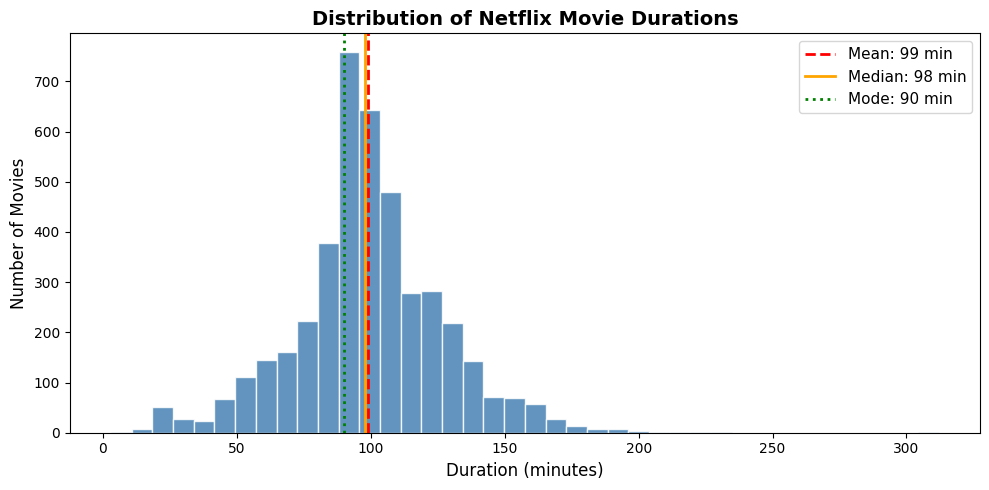

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(movies['duration_mins'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)

# Add vertical lines for mean and median
ax.axvline(mean_duration, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_duration:.0f} min')
ax.axvline(median_duration, color='orange', linestyle='-', linewidth=2, label=f'Median: {median_duration:.0f} min')
ax.axvline(mode_duration, color='green', linestyle=':', linewidth=2, label=f'Mode: {mode_duration:.0f} min')

ax.set_title('Distribution of Netflix Movie Durations', fontsize=14, fontweight='bold')
ax.set_xlabel('Duration (minutes)', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


> 💡 **What to notice:**
> - The shape of the histogram tells you if data is symmetric or skewed
> - See how mean, median, and mode line up (or don't!)
> - The spread of the bars reflects the standard deviation


---
### 📊 Chart 2 — Bar Chart: Top 10 Countries by Content


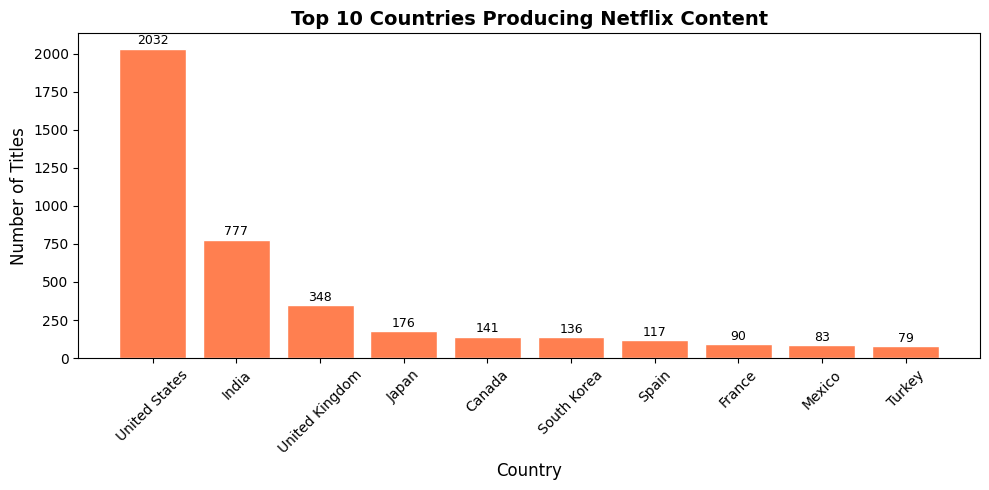

In [20]:
top_countries = df['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(top_countries.index, top_countries.values, color='coral', edgecolor='white')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

ax.set_title('Top 10 Countries Producing Netflix Content', fontsize=14, fontweight='bold')
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---
### 🥧 Chart 3 — Pie Chart: Movies vs TV Shows


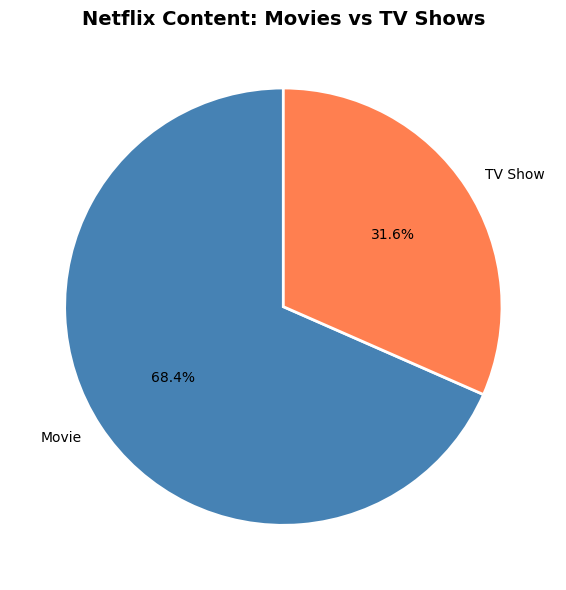

In [21]:
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(type_counts.values,
       labels=type_counts.index,
       autopct='%1.1f%%',
       colors=['steelblue', 'coral'],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax.set_title('Netflix Content: Movies vs TV Shows', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


---
### 📈 Chart 4 — Line Chart: How Has Content Grown Over the Years?


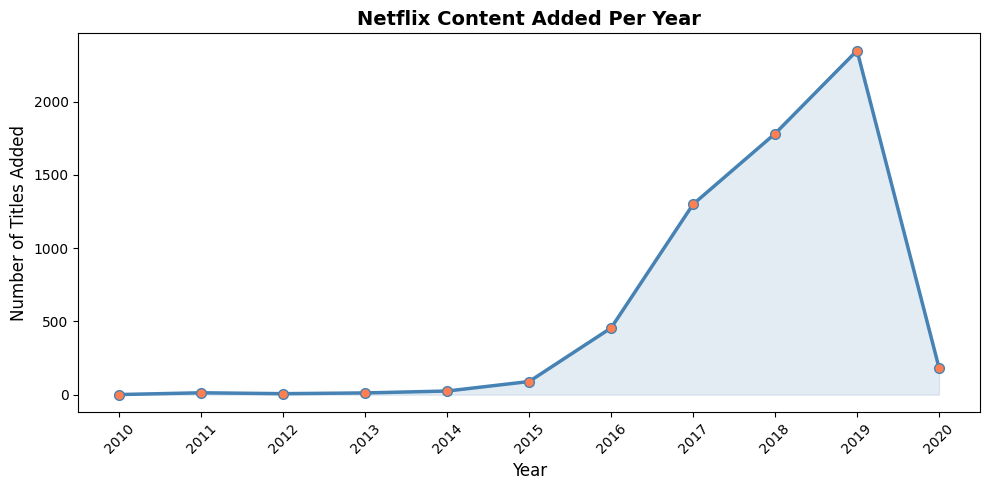

In [22]:
# Count titles added per year
df['year_added'] = df['date_added'].str.strip().str[-4:]  # extract year from date string
yearly = df['year_added'].value_counts().sort_index()

# Keep only reasonable years
yearly = yearly[yearly.index >= '2010']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(yearly.index, yearly.values, marker='o', color='steelblue',
        linewidth=2.5, markersize=7, markerfacecolor='coral')

ax.fill_between(yearly.index, yearly.values, alpha=0.15, color='steelblue')

ax.set_title('Netflix Content Added Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles Added', fontsize=12)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---
### 📦 Chart 5 — Box Plot: Duration by Content Type

A box plot is the most powerful chart for showing statistics visually.
It shows the median, quartiles, and outliers all at once.


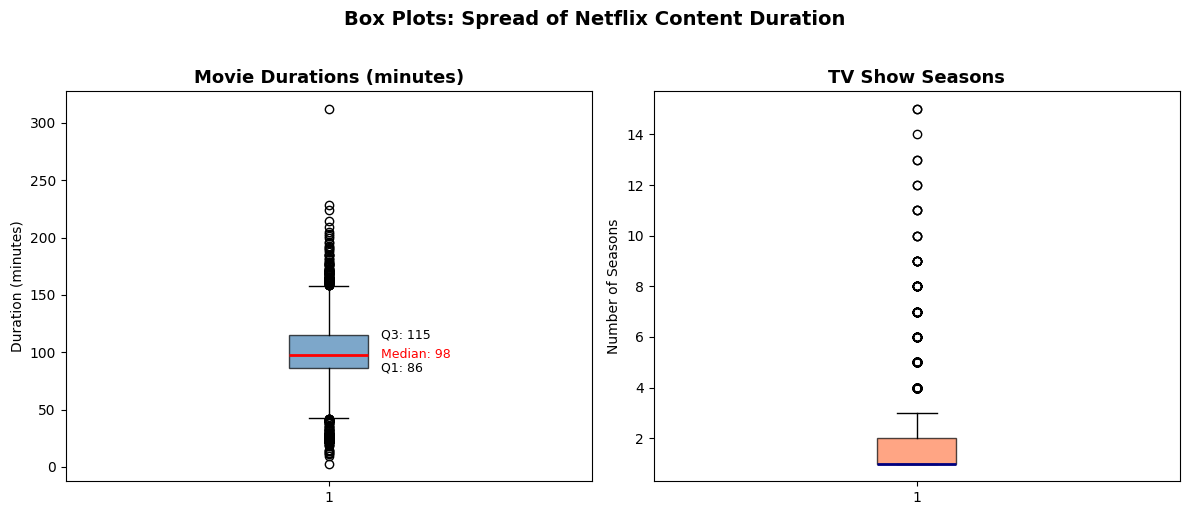

In [23]:
# Get durations for TV Shows (number of seasons) separately
tv_shows = df[df['type'] == 'TV Show'].copy()
tv_shows['seasons'] = tv_shows['duration'].str.extract(r'(\d+)').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot for movie durations
axes[0].boxplot(movies['duration_mins'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Movie Durations (minutes)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Duration (minutes)')

# Annotate the box plot
q1 = movies['duration_mins'].quantile(0.25)
q3 = movies['duration_mins'].quantile(0.75)
axes[0].text(1.1, median_duration, f'Median: {median_duration:.0f}', va='center', fontsize=9, color='red')
axes[0].text(1.1, q1, f'Q1: {q1:.0f}', va='center', fontsize=9)
axes[0].text(1.1, q3, f'Q3: {q3:.0f}', va='center', fontsize=9)

# Box plot for TV show seasons
axes[1].boxplot(tv_shows['seasons'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.7),
                medianprops=dict(color='navy', linewidth=2))
axes[1].set_title('TV Show Seasons', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Seasons')

plt.suptitle('Box Plots: Spread of Netflix Content Duration', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


> 💡 **How to read a box plot:**
> - The **line in the middle** = Median
> - The **box** = where the middle 50% of data sits (Q1 to Q3)
> - The **whiskers** = typical range
> - The **dots** beyond whiskers = outliers (unusual values)


---
## 🏋️ Step 5 — Your Turn! Student Challenges

Try these on your own. Use what you have learned above.


### 🟡 Challenge 1 (Easy)
Calculate the mean, median, and mode of **release_year** for movies.
What does this tell you about when most Netflix movies were originally released?


In [ ]:
# Your code here



### 🟠 Challenge 2 (Medium)
Filter the dataset to only include movies from **India**.
Then calculate the mean duration and compare it to the overall mean.
Are Indian movies longer or shorter than average?


In [ ]:
# Your code here



### 🔴 Challenge 3 (Hard)
Find the **top 5 directors** with the most movies on Netflix.
Then create a **bar chart** showing their movie counts.
Hint: Use `.value_counts()` and `.head(5)` on the `director` column (movies only).


In [ ]:
# Your code here



---
## 📋 Quick Reference Cheatsheet

| What you want | Pandas code |
|---|---|
| Load a CSV file | `pd.read_csv("file.csv")` |
| First 5 rows | `df.head()` |
| Column names | `df.columns` |
| Missing values | `df.isnull().sum()` |
| Count unique values | `df['col'].value_counts()` |
| Filter rows | `df[df['col'] == 'value']` |
| Select columns | `df[['col1', 'col2']]` |
| Mean | `df['col'].mean()` |
| Median | `df['col'].median()` |
| Mode | `df['col'].mode()[0]` |
| Variance | `df['col'].var()` |
| Standard deviation | `df['col'].std()` |
| All stats at once | `df['col'].describe()` |
| Bar chart | `ax.bar(x, y)` |
| Histogram | `ax.hist(data, bins=n)` |
| Line chart | `ax.plot(x, y)` |
| Pie chart | `ax.pie(values, labels=labels)` |
| Box plot | `ax.boxplot(data)` |

---
*Happy analysing!* 🎬📊
